## K-Nearest Neighbours (KNN) <a id="k-nearest-neighbours"></a>

## Table of Contents
* [K-Nearest Neighbouts (KNN)](#k-nearest-neighbours)

K-Nearest Neighbours (KNN), similarly to Decision Trees and Random Forests, is one of the algorithms that is remarkable for its simplicity, but becomes increasingly more complicated as we dive deeper into it. However, we shall start slow and leave the more complex matters for later.

Consider a given point, with two features $(x_{1}, x_{2})$, that you want to classify. In KNN, we check the class of the K nearest points and use them as votes for the point we want to classify. The class that is the most voted across the K selected neighbours, is the class attributed to the given point. This is the basic idea of a KNN Classifier, from which you may raise many questions that hopefully will be answered below.

The first question we can raise is: how do we calculate the distance between our given point and any other point from which we know the class? By default, the distance metric considered is the Euclidean Distance, but other plausible contestants are considered. In [distances.ipynb](./metrics/distances.ipynb) you can find more information on the most common distances used. The scikit-learn library defaults to the Minkowski distance (with $p = 2$, which means it is, effectively, the Euclidean distance), but any other distance described in the mentioned notebook can be used, including the arguments mentioned.

If you wonder about the fairness of using the votes of the K-Nearest Neighbours to decide the a determined points class, no matter how far these points are, it is often to introduce a weighting algorithm. By default, each neighbours class weights the same, but in scenarios where the data is very sparse it is adequate to attribute a vote importance (weight) based on the distance the neighbouring points are from the one we desire to classify. scikit-learn allows you to use the distance as the weight of a neighbour vote, but that might be insufficient for your use case. For example, to compensate for the low number of samples of a certain class, you may attribute a larger weight to the neighbors belonging to it. You are free to integrate any weight metric that may suit your problem.

Because this algorithm is a lazy learner Machine Learning algorithm (it only learns from the training set in inference, when you are given the data point), calculating which are the K-nearest neighbours becomes an engineering problem as your dataset grows bigger. For small datasets, you can just compute the distances to all points (brute-force search) and it is the most intuitive way of thinking about KNN for the first time. However, imagine you have to find the K-nearest neighbours in a dataset with millions of points. For each point you want to classify, you will spend significant amounts of time to provide an expected label, and as you can see, a trivial approach soon becomes hard to compute. Without you having to think about it, scikit-learn selects between brute-forcing the search or using one of two other algorithms: Ball Tree or K-Dimensional Tree (or just KD Tree).

Let's start with the simpler and easier to understand approach: brute-force.

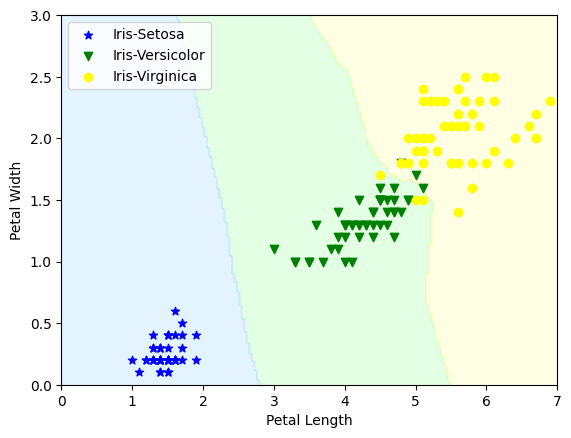

In [ ]:
"""Beginning of KNN code examples."""
from typing import cast, Dict
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

iris = cast(Dict, datasets.load_iris())
k = 5
X = iris["data"][:, 2:]
y = iris["target"]

# Euclidean distance
def calc_dist_euclidean(point1, point2):
    """Calculates the Euclidean distance between two given points."""
    current_sum = 0
    for coord in range(X.shape[1]):
        current_sum += (point1[coord] - point2[coord]) ** 2
    return current_sum ** ( 1 / 2 )

def predict_knn(x_train, y_train, point, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    # Get the distance of the point to every other
    # point in the training set (we considered the
    # whole dataset for demonstration purposes)
    for idx, train_point in enumerate(x_train):
        euclidean_dist = calc_dist_euclidean(point, train_point)
        dists.append((euclidean_dist, y_train[idx]))

    # Sort ascending
    dists.sort(key=lambda tup: tup[0])
    # Get the K closest points
    votes = dists[:k_neigh]
    # Count the total number of votes per class in
    # these K points
    total_votes = np.zeros(len(np.unique(y_train)))
    for vote in votes:
        total_votes[vote[1]] += 1
    # Prediction is the class with the largest amount
    # of votes (in a tie scenario, picks the one with
    # lowest index)
    return int(np.argmax(total_votes))

x_min, x_max = 0, 7
y_min, y_max = 0, 3

# Creates a dataset with every point in the plot, to
# show the predicted class in each set of coordinates
# and plots it
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample] = predict_knn(x_train=X,
                                      y_train=y,
                                      point=data_points[sample, :],
                                      k_neigh=k)

predictions = predictions.reshape(xx.shape)

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend(loc=2)
plt.show()


In the interactive code below, you can choose a set of coordinates (which will appear in the color pink and with the marker of the predicted class) and its corresponding K closest points will appear as red!

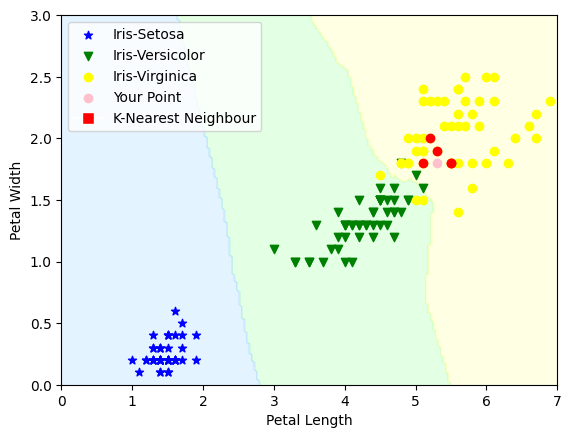

In [ ]:
from typing import cast, Dict
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

your_point = [5.3, 1.8] # your point with coordinates [x,y]

iris = cast(Dict, datasets.load_iris())
X = iris["data"][:, 2:]
y = iris["target"]

k = 5

def calc_dist_euclid_2(point1, point2):
    """Calculates the Euclidean distance between
    two given points."""
    current_sum = 0
    for coord in range(X.shape[1]):
        current_sum += (point1[coord] - point2[coord]) ** 2
    return current_sum ** ( 1 / 2 )

def predict_knn_2(x_train, y_train, point, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    for idx, train_point in enumerate(x_train):
        dist = calc_dist_euclid_2(point, train_point)
        dists.append((dist, y_train[idx], train_point))

    dists.sort(key=lambda tup: tup[0])
    votes = dists[:k_neigh]
    total_votes = np.zeros(len(np.unique(y_train)))
    k_neighbours_list = []
    for vote in votes:
        total_votes[vote[1]] += 1
        k_neighbours_list.append((vote[2], vote[1]))
    return np.argmax(total_votes), k_neighbours_list

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample], _ = predict_knn_2(x_train=X,
                                           y_train=y,
                                           point=data_points[sample, :],
                                           k_neigh=k)

predictions = predictions.reshape(xx.shape)

your_point_class = int(predict_knn_2(X, y, point=your_point, k_neigh=k)[0])
k_neighbours = predict_knn_2(X, y, point=your_point, k_neigh=k)[1]

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

plt.scatter(your_point[0],
            your_point[1],
            marker=label_to_marker[your_point_class],
            c="pink",
            label="Your Point")

for neighbour_idx in range(k):
    marker = label_to_marker[k_neighbours[neighbour_idx][1]]
    plt.scatter(
        k_neighbours[neighbour_idx][0][0],
        k_neighbours[neighbour_idx][0][1],
        marker=marker,
        c="red"
    )

knn_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='K-Nearest Neighbour'
)
handles, labels = plt.gca().get_legend_handles_labels()

handles.append(knn_legend)
labels.append("K-Nearest Neighbour")

plt.legend(handles, labels, loc=2)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()


In this example, we hand-coded most commonly used distance to show you a quick draft on the decision boundaries imposed by this algorithm on our given dataset. But, as you could have noticed by exploring the [distances notebook](./metrics/distances.ipynb), there are multiple distance metrics that can be used in the KNN algorithm and each of these provides different classification boundaries. Below, some distance metrics were selected and plotted to show you the impact that the metric selection has.

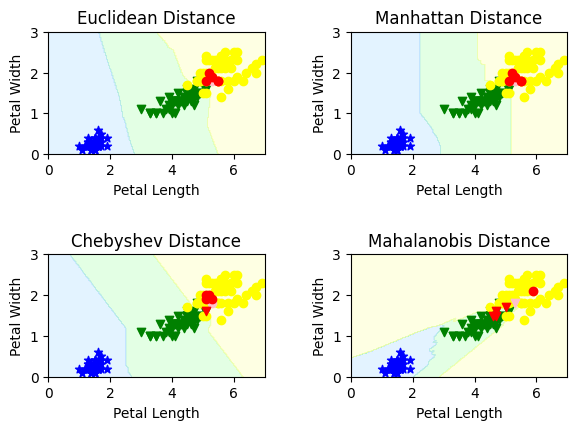

In [ ]:
from typing import cast, Dict
from sklearn import datasets
from sklearn.metrics import DistanceMetric
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from math import ceil

your_point = [5.3, 1.8] # your point with coordinates [x,y]

iris = cast(Dict, datasets.load_iris())
X = iris["data"][:, 2:]
y = iris["target"]

k = 5

distances = {
    "euclidean": DistanceMetric.get_metric('euclidean'),
    "manhattan": DistanceMetric.get_metric('manhattan'),
    "chebyshev": DistanceMetric.get_metric('chebyshev'),
    "mahalanobis": DistanceMetric
}

def get_dist(dist_name, x: np.ndarray | None) -> DistanceMetric:
    """Gets the corresponding DistanceMetric object for a given
    distance name."""
    if dist_name == 'mahalanobis' and x is not None:
        # rowvar=False indicates that the variables are represented in the
        # columns rather than the rows
        return DistanceMetric.get_metric('mahalanobis', V=np.cov(x, rowvar=False))
    return distances[dist_name]

def calc_dist(dist_name, point1, point2, x: None):
    """Calculates the selected distance between two given points.
    In case the calculated distance is Mahalanobis, requires the
    `x` matrix."""
    dist_fun = get_dist(dist_name, x)
    dist_scalar = dist_fun.pairwise(np.array([point1]),
                                    np.array([point2]))
    return dist_scalar

def predict_knn_3(x_train, y_train, point, dist_name, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    for idx, train_point in enumerate(x_train):
        dist = calc_dist(dist_name, point, train_point, x_train)
        dists.append((dist, y_train[idx], train_point))

    dists.sort(key=lambda tup: tup[0])
    votes = dists[:k_neigh]
    total_votes = np.zeros(len(np.unique(y_train)))
    k_neighbours_md = []
    for vote in votes:
        total_votes[vote[1]] += 1
        k_neighbours_md.append((vote[2], vote[1]))
    return np.argmax(total_votes), k_neighbours_md

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

ROWS = 2
cols = ceil(len(distances.keys()) / 2)
fig, axes = plt.subplots(ROWS, cols)
axes = axes.flatten()

for index, distance_name in enumerate(distances):
    predictions = np.zeros(data_points.shape[0])
    for sample in range(data_points.shape[0]):
        predictions[sample], _ = predict_knn_3(x_train=X,
                                               y_train=y,
                                               point=data_points[sample, :],
                                               dist_name=distance_name,
                                               k_neigh=k)

    predictions = predictions.reshape(xx.shape)

    your_point_class = int(predict_knn_3(X,
                                         y,
                                         point=your_point,
                                         dist_name=distance_name,
                                         k_neigh=k)[0])
    k_neighbours = predict_knn_3(X,
                                 y,
                                 point=your_point,
                                 dist_name=distance_name,
                                 k_neigh=k)[1]

    X_setosa = X[y==0]
    X_versicolor = X[y==1]
    X_virginica = X[y==2]

    cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

    axes[index].axis((0.,7., 0.,3.))
    axes[index].contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
    axes[index].scatter(X_setosa[:,0],
                X_setosa[:,1],
                marker="*",
                c="blue", label="Iris-Setosa")
    axes[index].scatter(X_versicolor[:,0],
                X_versicolor[:,1],
                marker="v",
                c="green",
                label="Iris-Versicolor")
    axes[index].scatter(X_virginica[:,0],
                X_virginica[:,1],
                marker="o",
                c="yellow",
                label="Iris-Virginica")

    label_to_marker = {
        0: "*",
        1: "v",
        2: "o",
    }

    axes[index].scatter(your_point[0],
                your_point[1],
                marker=label_to_marker[your_point_class],
                c="pink",
                label="Your Point")

    for neighbour_idx in range(k):
        marker = label_to_marker[k_neighbours[neighbour_idx][1]]
        axes[index].scatter(
            k_neighbours[neighbour_idx][0][0],
            k_neighbours[neighbour_idx][0][1],
            marker=marker,
            c="red"
        )

    axes[index].set_xlabel("Petal Length")
    axes[index].set_ylabel("Petal Width")

    axes[index].set_title(f"{distance_name.capitalize()} Distance")

plt.tight_layout(pad=2.5)
plt.show()


The multiple graphics generated above are illustrative of the different decision boundaries created when varying the distance metric. The boundaries both in Manhattan and Chebyshev can be described through linear equations, without much of a curvature and rather incremental steps. This trend becomes easier to spot in the points further away from the features data points. It is easy to develop some intuition in these distances, as well as in the Euclidean distance, as the points that appear visually closer tend to be the closest neighbours. However, the Mahalanobis distance shows some stranger decision boundaries that are hard to visualize without plotting it. In this distance, it is possible to see in the graphic that even though the yellow points are the furthest (considering Euclidean distance) from those that have a petal length smaller than 2, these are the ones that are closer in the Mahalanobis distance. This happens because of the larger variance seen in both variables of the yellow data points. To develop some intuition, see this as the probability of a point in the plot belonging to a specific class: if a point appears further away from the data points, then it most likely belongs to the class with highest variance. Therefore, it is also safe to extend our thought to the fact that the closest point from class A to any point P, in the Mahalanobis distance, is always the point closest to the mean point of that class A.